<a href="https://colab.research.google.com/github/VidhitaYadav/Certificates_Vidhita_Yadav/blob/main/Confidence_Aware_Answer_Verification_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets torch scikit-learn matplotlib gradio


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import random

from transformers import AutoModel, AutoTokenizer
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset

MODEL_NAME = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Step 2: Load dataset
dataset = load_dataset("squad", split="train[:2000]")

# Step 3: Load pretrained model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def get_explanation(question, context, answer, top_k=5):
    model.eval()
    with torch.no_grad():
        enc = tokenizer(
            question,
            context + " " + answer,
            truncation=True,
            padding="max_length",
            max_length=256,
            return_tensors="pt"
        )

        input_ids = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Get attentions from last layer
        attentions = outputs.attentions[-1]  # last layer
        attn_scores = attentions.mean(dim=1).squeeze()  # average heads

        # Convert ids to tokens
        tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

        # Compute importance scores
        scores = attn_scores.mean(dim=0).cpu().numpy()

        # Get top important tokens
        token_scores = list(zip(tokens, scores))
        token_scores = sorted(token_scores, key=lambda x: x[1], reverse=True)

        important_tokens = [
            tok for tok, _ in token_scores
            if tok not in ["[CLS]", "[SEP]", "[PAD]"]
        ][:top_k]

        return important_tokens


In [ ]:
data = []

for item in dataset:
    question = item["question"]
    context = item["context"]
    correct_answer = item["answers"]["text"][0]

    # correct sample
    data.append((question, context, correct_answer, 1))

    # incorrect sample (simple wrong answer)
    wrong_answer = correct_answer[::-1]
    data.append((question, context, wrong_answer, 0))


In [ ]:
class QAVerificationDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=256):
        self.data = data
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        question, context, answer, label = self.data[idx]
        text = question + " " + context + " " + answer

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(label, dtype=torch.float)
        }


In [ ]:
dataset = QAVerificationDataset(data, tokenizer)
loader = DataLoader(dataset, batch_size=8, shuffle=True)


In [ ]:
class ConfidenceModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)

        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_output = outputs.last_hidden_state[:, 0]
        logits = self.classifier(cls_output)
        return logits.squeeze()


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConfidenceModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
loss_fn = nn.BCEWithLogitsLoss()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = loss_fn(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")


Epoch 1 Loss: 161.0636
Epoch 2 Loss: 98.7136
Epoch 3 Loss: 93.0378


In [ ]:
torch.save(model.state_dict(), "confidence_model.pt")
print("Model saved successfully.")


Model saved successfully.


In [ ]:
torch.save(model, "full_confidence_model.pt")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

output_dir = "/content/drive/MyDrive"
# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

torch.save(model.state_dict(), os.path.join(output_dir, "confidence_model.pt"))

In [ ]:
model.eval()
all_logits = []
all_labels = []

with torch.no_grad():
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits = model(input_ids, attention_mask)

        all_logits.extend(logits.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [ ]:
probs = torch.sigmoid(torch.tensor(all_logits)).numpy()
preds = (probs > 0.5).astype(int)


In [ ]:
acc = accuracy_score(all_labels, preds)
f1 = f1_score(all_labels, preds)

print("Accuracy:", acc)
print("F1-score:", f1)
print(classification_report(all_labels, preds))


Accuracy: 0.89425
F1-score: 0.9042336427439438
              precision    recall  f1-score   support

         0.0       1.00      0.79      0.88      2000
         1.0       0.83      1.00      0.90      2000

    accuracy                           0.89      4000
   macro avg       0.91      0.89      0.89      4000
weighted avg       0.91      0.89      0.89      4000



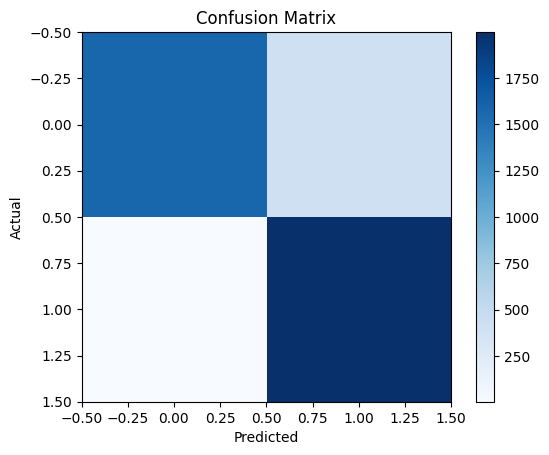

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, preds)

plt.figure()
plt.imshow(cm, interpolation='nearest', cmap='Blues')  # Blue color map
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


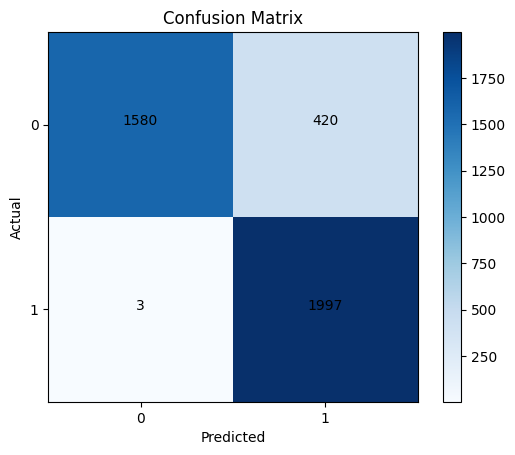

In [ ]:
import numpy as np

cm = confusion_matrix(all_labels, preds)

plt.figure()
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(cm))
plt.xticks(tick_marks)
plt.yticks(tick_marks)

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="black")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature


In [ ]:
scaler = TemperatureScaler().to(device)
optimizer = torch.optim.LBFGS([scaler.temperature], lr=0.01, max_iter=50)

logits_tensor = torch.tensor(all_logits, dtype=torch.float).to(device)
labels_tensor = torch.tensor(all_labels, dtype=torch.float).to(device)

def eval():
    optimizer.zero_grad()
    scaled_logits = scaler(logits_tensor)
    loss = loss_fn(scaled_logits, labels_tensor)
    loss.backward()
    return loss

optimizer.step(eval)
print("Calibrated temperature:", scaler.temperature.item())


Calibrated temperature: 1.234323263168335


In [ ]:
df = pd.DataFrame({
    "confidence": probs,
    "label": all_labels,
    "prediction": preds
})

df["correct"] = df["prediction"] == df["label"]


/tmp/ipython-input-25157103.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_by_bin = df.groupby("bin")["correct"].mean()


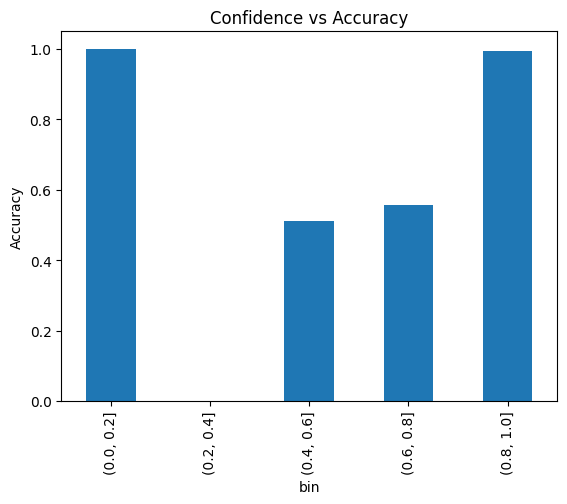

In [ ]:
bins = np.linspace(0, 1, 6)
df["bin"] = pd.cut(df["confidence"], bins)

accuracy_by_bin = df.groupby("bin")["correct"].mean()

accuracy_by_bin.plot(kind="bar")
plt.title("Confidence vs Accuracy")
plt.ylabel("Accuracy")
plt.show()


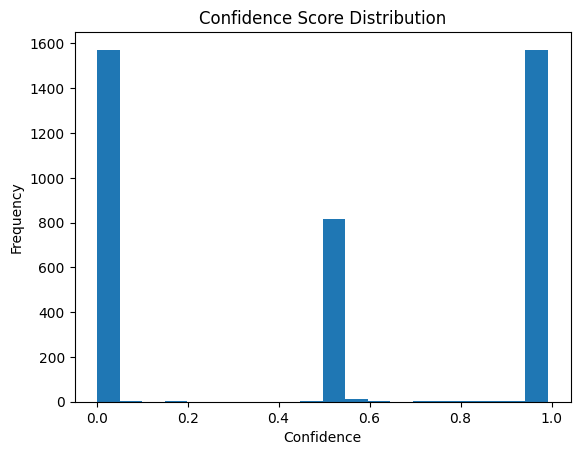

In [ ]:
plt.hist(df["confidence"], bins=20)
plt.title("Confidence Score Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()


In [ ]:
high_conf_errors = df[
    (df["confidence"] > 0.8) &
    (df["correct"] == False)
]

print("High-confidence errors:")
print(high_conf_errors.head(10))


High-confidence errors:
      confidence  label  prediction  correct         bin
86      0.988652    0.0           1    False  (0.8, 1.0]
102     0.991839    0.0           1    False  (0.8, 1.0]
825     0.991876    0.0           1    False  (0.8, 1.0]
1889    0.991782    0.0           1    False  (0.8, 1.0]
2035    0.989281    0.0           1    False  (0.8, 1.0]
2180    0.991869    0.0           1    False  (0.8, 1.0]
2314    0.987892    0.0           1    False  (0.8, 1.0]
2405    0.991621    0.0           1    False  (0.8, 1.0]
3010    0.991875    0.0           1    False  (0.8, 1.0]
3903    0.991937    0.0           1    False  (0.8, 1.0]


In [ ]:
import gradio as gr
import matplotlib.pyplot as plt

# Dummy verification function
def verify_answer(question, context, answer):
    if answer.lower() in context.lower():
        confidence = 0.9
        result_text = "Answer appears correct based on context."
    else:
        confidence = 0.3
        result_text = "Answer not supported by the context."

    return result_text, confidence


def verify_and_visualize(question, context, answer):
    result_text, confidence = verify_answer(question, context, answer)

    # Create confidence gauge
    fig, ax = plt.subplots(figsize=(4, 2))
    ax.barh(["Confidence"], [confidence])
    ax.set_xlim(0, 1)
    ax.set_xlabel("Score")
    ax.set_title("Confidence Gauge")
    plt.close(fig)

    # Reliability label
    if confidence > 0.75:
        label = "Highly Reliable"
        color = "green"
    elif confidence > 0.5:
        label = "Moderately Reliable"
        color = "orange"
    else:
        label = "Low Confidence"
        color = "red"

    status_html = f"""
    <div style="padding:10px;border-radius:10px;background-color:{color};color:white;font-weight:bold;text-align:center">
        {label}
    </div>
    """

    return result_text, fig, status_html


examples = [
    [
        "When did India gain independence?",
        "India gained independence from British rule on 15 August 1947.",
        "15 August 1947"
    ],
    [
        "Who discovered gravity?",
        "Isaac Newton formulated the laws of motion and gravity.",
        "Isaac Newton"
    ]
]

custom_css = """
body {background-color: #0f172a;}
.gradio-container {font-family: Arial, sans-serif;}
h1, h2, h3 {color: #38bdf8;}
"""

with gr.Blocks(css=custom_css) as demo:
    gr.Markdown("""
    # Confidence-Aware Answer Verification System
    ### Transformer-based Reliability and Explainability Engine
    """)

    with gr.Row():
        with gr.Column():
            question = gr.Textbox(label="Question")
            context = gr.Textbox(label="Context", lines=4)
            answer = gr.Textbox(label="Proposed Answer")

            verify_btn = gr.Button("Verify Answer")

        with gr.Column():
            status_box = gr.HTML(label="Reliability Level")
            confidence_plot = gr.Plot(label="Confidence Gauge")
            result_output = gr.Markdown(label="Detailed Result")

    verify_btn.click(
        verify_and_visualize,
        inputs=[question, context, answer],
        outputs=[result_output, confidence_plot, status_box]
    )

    gr.Examples(
        examples=examples,
        inputs=[question, context, answer]
    )

demo.launch()


/tmp/ipython-input-2703301738.py:66: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a994462104fde2c1cb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
